In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
dir = './data'
train_sequences = pd.read_pickle(f"{dir}/train_sequences.pkl")
test_sequences = pd.read_pickle(f"{dir}/test_sequences.pkl")

In [3]:
train_sequences.shape, test_sequences.shape

((285980, 34), (291575, 34))

In [4]:
train_sequences.head(1)

,date,smart_9_raw,smart_197_raw,smart_241_raw,smart_242_raw,smart_7_raw,smart_193_raw,smart_1_raw,smart_240_raw,smart_198_raw,...,smart_196_raw,smart_183_raw,smart_199_raw,smart_200_raw,smart_225_raw,serial_number,model,capacity_bytes,failure,label
0,2016-10-13,0.722535,0.0,0.0,0.0,0.0,0.000369,0.0,0.0,0.0,...,0.714656,0.0,0.0,0.0,0.0,MJ0351YNG9ZJAA,Hitachi HDS5C3030ALA630,3.000593e+12,0.0,1


### Splitting and Reshaping Train/Test

In [3]:
X_train = train_sequences.drop(columns=['label', 'serial_number', 'date', 'model', 'capacity_bytes', 'failure'])
y_train = train_sequences['label']

In [4]:
X_train.shape, y_train.shape

((285980, 28), (285980,))

In [5]:
X_test = test_sequences.drop(columns=['label', 'serial_number', 'date', 'model', 'capacity_bytes', 'failure'])
y_test = test_sequences['label']

In [6]:
X_test.shape, y_test.shape

((291575, 28), (291575,))

In [7]:
X_train.columns

Index(['smart_9_raw', 'smart_197_raw', 'smart_241_raw', 'smart_242_raw',
       'smart_7_raw', 'smart_193_raw', 'smart_1_raw', 'smart_240_raw',
       'smart_198_raw', 'smart_194_raw', 'smart_4_raw', 'smart_12_raw',
       'smart_187_raw', 'smart_192_raw', 'smart_190_raw', 'smart_5_raw',
       'smart_3_raw', 'smart_195_raw', 'smart_189_raw', 'smart_191_raw',
       'smart_2_raw', 'smart_188_raw', 'smart_8_raw', 'smart_196_raw',
       'smart_183_raw', 'smart_199_raw', 'smart_200_raw', 'smart_225_raw'],
      dtype='str')

In [8]:
sequence_length = 5
num_features = X_train.shape[1]

In [9]:
def create_sequences(df, feature_cols, sequence_length):
    X = []
    y = []

    for drive in df['serial_number'].unique():
        df_drive = df[df['serial_number'] == drive].sort_values('date')

        data = df_drive[feature_cols].values
        labels = df_drive['label'].values

        for i in range(len(df_drive) - sequence_length):
            X.append(data[i:i+sequence_length])
            y.append(labels[i+sequence_length-1])

    return np.array(X), np.array(y)

In [10]:
feature_cols = X_train.columns.tolist()

X_train, y_train = create_sequences(train_sequences, feature_cols, 5)
X_test, y_test = create_sequences(test_sequences, feature_cols, 5)

In [11]:
X_train.shape, y_train.shape

((281875, 5, 28), (281875,))

In [12]:
X_test.shape, y_test.shape

((287225, 5, 28), (287225,))

In [13]:
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([280618,   1257]))


### Modeling

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tcn import TCN
import tensorflow as tf

In [16]:
kernel_size = 2
filters = 64
lstm_units = 64
dropout_rate = 0.3
recurrent_dropout_rate = 0.2
l2_lambda = 0.001

In [17]:
model = Sequential()

model.add(
    TCN(
        nb_filters=64,
        kernel_size=3,
        dilations=[1, 2, 4, 8],
        dropout_rate=0.3,
        return_sequences=False,
        input_shape=(sequence_length, num_features)
    )
)

model.add(
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

C:\Users\affi-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tcn\tcn.py:268: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(TCN, self).__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn (TCN)                       │ (None, 64)             │        93,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,033 (390.75 KB)

 Trainable params: 100,033 (390.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',tf.keras.metrics.AUC(name='auc')]
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    class_weight={0: 1, 1: 50}
)

Epoch 1/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.9951 - auc: 0.6453 - loss: 0.5968 - val_accuracy: 0.9946 - val_auc: 0.7119 - val_loss: 0.2187
Epoch 2/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - accuracy: 0.9944 - auc: 0.6339 - loss: 0.5805 - val_accuracy: 0.9950 - val_auc: 0.7075 - val_loss: 0.2109
Epoch 3/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9934 - auc: 0.6472 - loss: 0.5675 - val_accuracy: 0.9946 - val_auc: 0.7081 - val_loss: 0.2315
Epoch 4/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9927 - auc: 0.6447 - loss: 0.5680 - val_accuracy: 0.9946 - val_auc: 0.7221 - val_loss: 0.1894
Epoch 5/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9921 - auc: 0.6481 - loss: 0.5689 - val_accuracy: 0.9937 - val_auc: 0.7091 - val_loss: 0.2086
Epoch 6/10
2203/2203 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.9924 - auc: 0.6422 - loss: 0.5718 - val_accuracy: 0.9946 - val_auc: 0.7044 - val_loss: 0.2076
Epoch 7/10
2203/

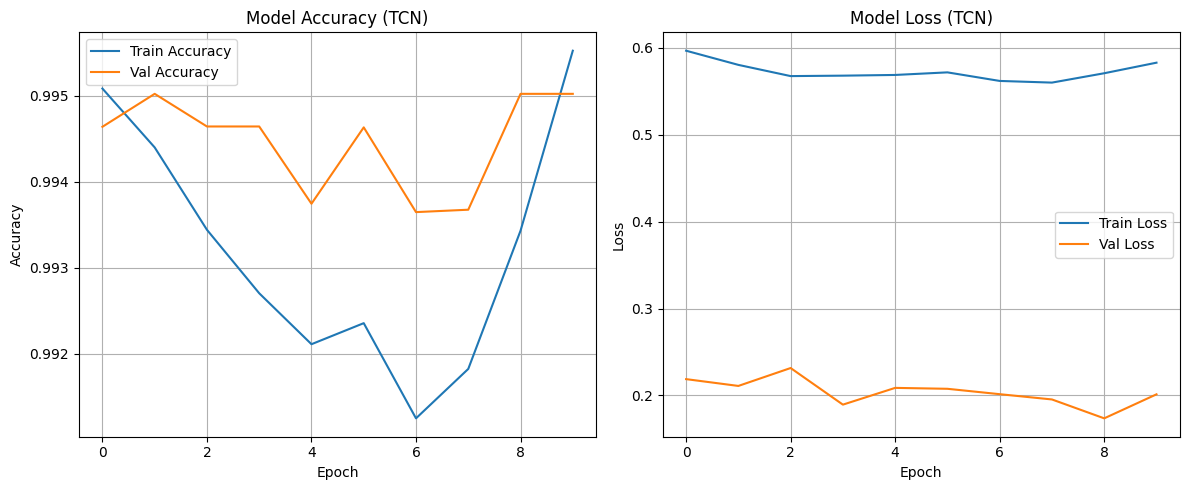

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy (TCN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (TCN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)


8976/8976 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step


8976/8976 ━━━━━━━━━━━━━━━━━━━━ 103s 11ms/step


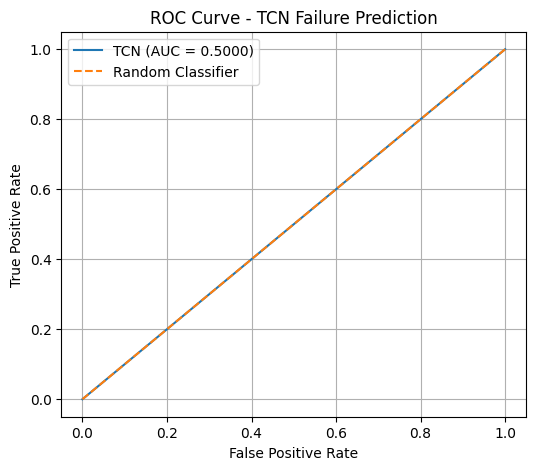

In [22]:
from sklearn.metrics import roc_curve, auc

y_proba = model.predict(X_test).ravel()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'TCN (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], '--', label='Random Classifier')
plt.title('ROC Curve - TCN Failure Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

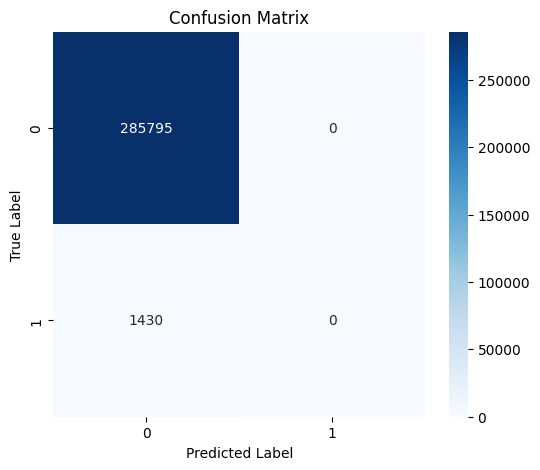

In [29]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    285795
           1       0.00      0.00      0.00      1430

    accuracy                           1.00    287225
   macro avg       0.50      0.50      0.50    287225
weighted avg       0.99      1.00      0.99    287225



C:\Users\affi-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\affi-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\affi-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas